In [1]:
import os, glob
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "Arial"
from matplotlib.ticker import ScalarFormatter
plt.rcParams['axes.linewidth'] = 1.5 # set the value globally
plt.rcParams["figure.dpi"] = 150
plt.rcParams['axes.grid'] = True
warnings.filterwarnings("ignore")
from matplotlib.ticker import ScalarFormatter

In [2]:
folder_path = r'C:\Project\PM4_MRD\Modulus reduction DSS'

### Inputs

In [36]:
conf_list = [0.25, 0.5, 1.0, 2.0, 4.0]
G0 = 677
Dr = 0.55
hpo = 0.40

In [ ]:
filepath = os.path.join(folder_path, 'Cyc_strain_DSS_Mod_&_Damp.csv')
df = pd.read_csv(filepath)
df = df.drop_duplicates(subset=['Strain amp (%)'], keep='last')

,Strain amp (%),G1(atm),G/Gmax1,D1(%),G2(atm),G/Gmax2,D2(%),G3(atm),G/Gmax3,D3(%),G4(atm),G/Gmax4,D4(%),G5(atm),G/Gmax5,D5(%)
1,0.0003,416.6480,1.010100,-0.000003,589.2300,1.010100,-0.000002,833.2970,1.010100,-9.323850e-07,1178.460,1.010100,-5.160200e-07,1666.600,1.010100,-2.972090e-07
3,0.0010,406.0490,0.984405,0.911925,582.1600,0.997981,0.495766,831.7470,1.008220,9.610650e-02,1178.460,1.010100,-5.717500e-06,1666.590,1.010100,-3.292950e-06
5,0.0030,370.4060,0.897993,3.153520,545.3580,0.934892,2.237810,792.6450,0.960824,1.531620e+00,1144.520,0.981012,1.001230e+00,1642.350,0.995407,5.764280e-01
7,0.0100,295.6220,0.716692,8.128250,449.3840,0.770366,6.518870,681.5720,0.826184,4.986760e+00,1021.400,0.875481,3.726000e+00,1514.740,0.918064,2.638860e+00
9,0.0300,211.3940,0.512492,13.029500,335.9240,0.575865,11.404000,529.8330,0.642249,9.966190e+00,817.257,0.700500,8.513560e+00,1264.450,0.766366,6.911800e+00
11,0.1000,129.8800,0.314874,19.338900,214.1620,0.367132,17.803400,347.2430,0.420919,1.596660e+01,563.120,0.482671,1.428140e+01,885.258,0.536543,1.290890e+01
13,0.3000,69.6453,0.168845,26.711700,120.9810,0.207395,24.685500,206.9040,0.250804,2.267810e+01,349.613,0.299666,2.041250e+01,576.853,0.349623,1.863700e+01
15,1.0000,26.9944,0.065444,34.734600,50.9725,0.087381,33.424400,96.0682,0.116451,3.151030e+01,169.660,0.145422,2.885510e+01,294.452,0.178463,2.644160e+01


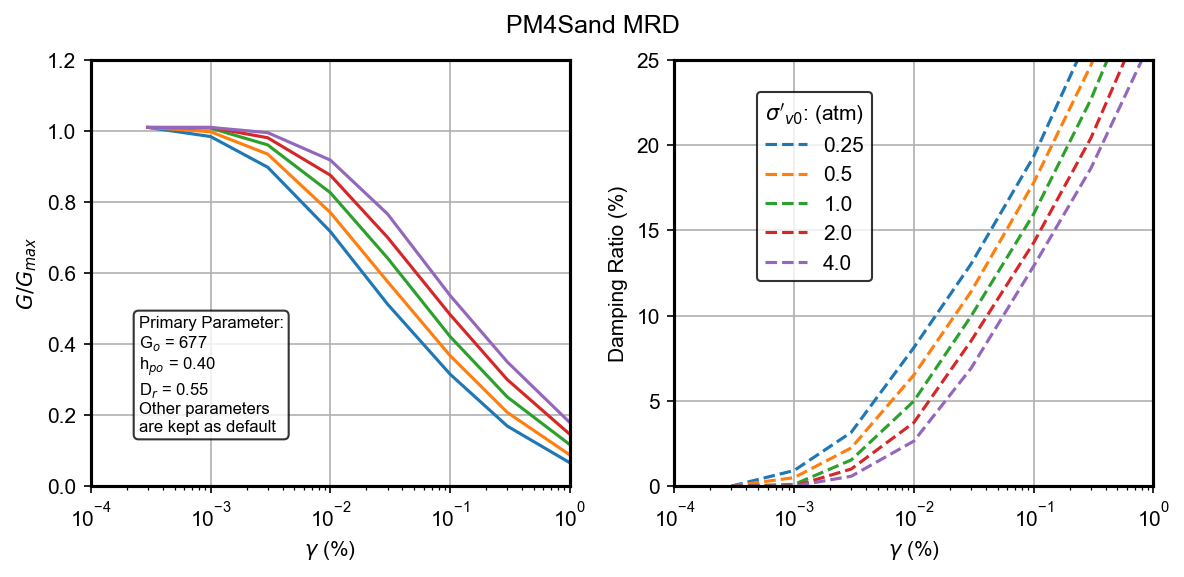

In [54]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

# Plot G/GmaxX (modulus reduction) on the left y-axis
for i in range(1, 6):
    
    axs[0].plot(df['Strain amp (%)'], df[f' G/Gmax{i}'])


axs[0].set_ylabel(r'$G/G_{max}$')

axs[0].set_ylim(0, 1.2)


# Create a second y-axis for Damping Ratio

# Plot DX(%) (damping) on the right y-axis
for i in range(1, 6):
    conf = conf_list[i-1]
    axs[1].plot(df['Strain amp (%)'], df[f' D{i}(%)'], '--', label=conf)

axs[1].set_ylabel('Damping Ratio (%)')
axs[1].set_ylim(0, 25)

for ax in axs:
    ax.set_xscale('log')
    ax.set_xlim(1e-4, 1)
    ax.set_xlabel(r'$\gamma$ (%)')
    ax.grid(True)

axs[1].legend(
    title=r"$\sigma'_{v0}$: (atm)",
    loc='upper left',
    bbox_to_anchor=(0.15, 0.95),
    frameon=True,
    fancybox=True,
    facecolor='white',
    edgecolor='black'
)
textstr0 = '\n'.join((
        r'Primary Parameter:',
        r'G$_{o}$ = %.0f' % (G0),
        r'h$_{po}$ = %.2f' % (hpo),
        r'D$_{r}$ = %.2f' % (Dr),
        r'Other parameters',
        r'are kept as default'))
axs[0].text(
    0.1, 0.4, textstr0, fontsize=8,
    transform=axs[0].transAxes, 
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
fig.suptitle('PM4Sand MRD', y=0.95)
plt.tight_layout()
plt.show()

In [ ]:
lab_datafile = r''